# 📈 Logistic Regression for Stock Movement Prediction
### *Teaching Notebook — Concept to Code*

---

**Learning Objectives**

By the end of this notebook, students will be able to:
1. Understand how logistic regression models a binary outcome
2. Compute financial technical indicators (RSI, Moving Averages)
3. Train a logistic regression model to predict next-day stock movement
4. Evaluate the model and interpret its outputs

---

## 🧠 Section 1 — The Big Idea

**Question:** Can we predict whether a stock will go *up* or *down* tomorrow?

This is a **binary classification** problem:
- Output = **1** → Stock goes UP
- Output = **0** → Stock goes DOWN

### The Sigmoid Function

Logistic regression uses the **sigmoid function** to squish any number into a probability between 0 and 1:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-(\beta_0 + \beta x)}}$$

- If the output > 0.5 → predict **UP (1)**
- If the output < 0.5 → predict **DOWN (0)**

### Features We Will Use

| Feature | What it measures |
|---------|------------------|
| **RSI** | Relative Strength Index — is the stock overbought or oversold? |
| **MA5** | 5-day moving average — short-term trend |
| **MA20** | 20-day moving average — medium-term trend |

---
## 📦 Section 2 — Install & Import Libraries

In [49]:
# Run this cell first to install required libraries
!pip install yfinance scikit-learn matplotlib seaborn pandas numpy --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 14.9 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries imported successfully!')

All libraries imported successfully!



## 📥 Section 3 — Load Real Stock Data

We use **Apple (AAPL)** stock from 2022 to 2024 — 3 years of daily prices, ~750 trading days.

In [2]:
# Download AAPL data
ticker = 'AAPL'
df = yf.download(ticker, start='2022-01-01', end='2024-12-31', auto_adjust=True)

# Flatten multi-level columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0].date()} → {df.index[-1].date()}')
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (752, 5)
Date range: 2022-01-03 → 2024-12-30


Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100


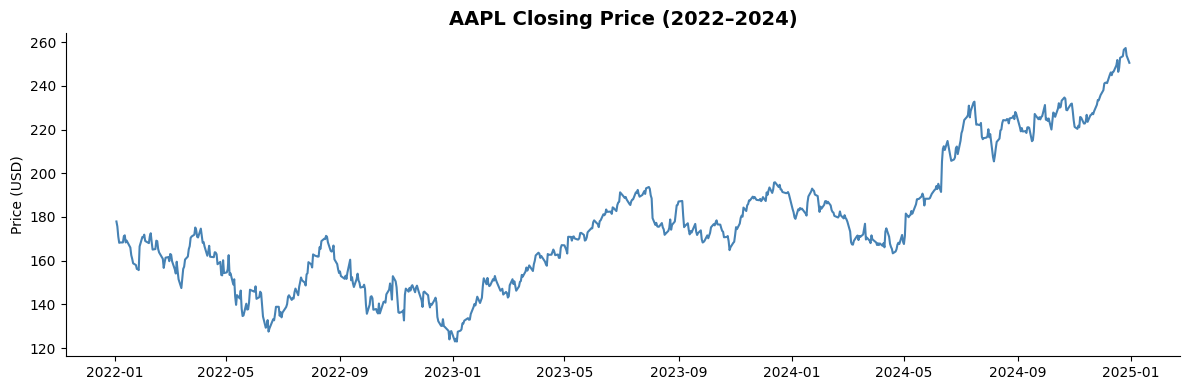

In [3]:
# 📊 Visualise the closing price
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
ax.set_title(f'{ticker} Closing Price (2022–2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [4]:
df.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100
2022-01-10,168.339310,168.642375,164.409205,165.298858,106765600
2022-01-11,171.164673,171.262428,166.999945,168.466400,76138300
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200
2022-01-13,168.339310,172.670234,167.948246,171.849023,84505800


---
## 🔧 Section 4 — Feature Engineering

We compute three technical indicators from the raw price data.

### 4a — Moving Averages (MA5 & MA20)

A **moving average** smooths out daily noise:
$$MA_n = \frac{\text{Close}_{t} + \text{Close}_{t-1} + \ldots + \text{Close}_{t-n+1}}{n}$$

- **MA5** captures short-term momentum
- **MA20** captures the medium-term trend
- When MA5 > MA20 → often a **bullish** signal

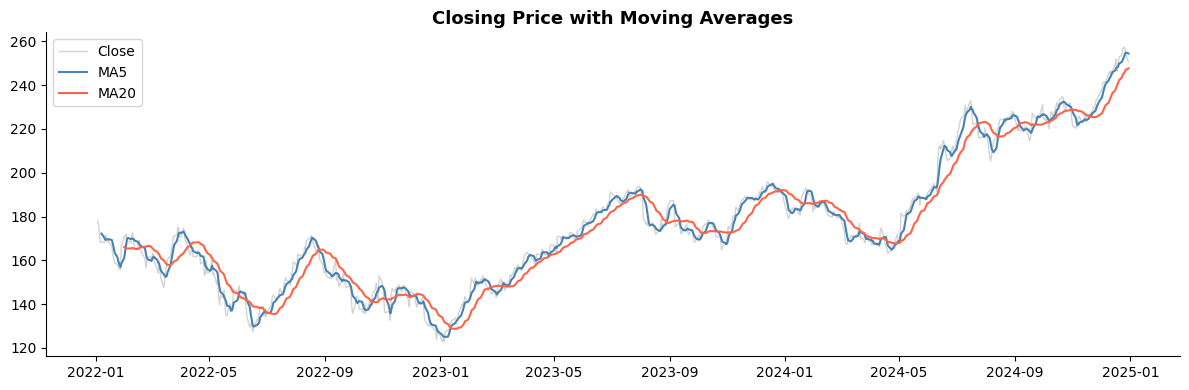

In [5]:
df['MA5']  = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df['Close'], label='Close',  color='lightgray', linewidth=1)
ax.plot(df.index, df['MA5'],   label='MA5',    color='steelblue', linewidth=1.5)
ax.plot(df.index, df['MA20'],  label='MA20',   color='tomato',    linewidth=1.5)
ax.set_title('Closing Price with Moving Averages', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# A new column MA5, MA20
df.head(25)

Price,Close,High,Low,Open,Volume,MA5,MA20
Date,,,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900,NaN,NaN
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400,NaN,NaN
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600,NaN,NaN
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000,NaN,NaN
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100,172.220547,NaN
2022-01-10,168.339310,168.642375,164.409205,165.298858,106765600,170.300461,NaN
2022-01-11,171.164673,171.262428,166.999945,168.466400,76138300,169.397125,NaN
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200,169.516397,NaN
2022-01-13,168.339310,172.670234,167.948246,171.849023,84505800,169.553540,NaN


### 4b — RSI (Relative Strength Index)

RSI measures the speed and magnitude of recent price changes:

$$RSI = 100 - \frac{100}{1 + RS} \quad \text{where} \quad RS = \frac{\text{Avg Gain}}{\text{Avg Loss}}$$

- **RSI > 70** → Overbought (stock may fall)
- **RSI < 30** → Oversold (stock may rise)
- RSI ranges from 0 to 100

---

## Average Gain & Average Loss

For a 14-day RSI, on each day you first compute the **daily change**:

$$\delta_t = \text{Close}_t - \text{Close}_{t-1}$$

Then split it into gain or loss:

$$\text{Gain}_t = \begin{cases} \delta_t & \text{if } \delta_t > 0 \\ 0 & \text{otherwise} \end{cases} \qquad \text{Loss}_t = \begin{cases} |\delta_t| & \text{if } \delta_t < 0 \\ 0 & \text{otherwise} \end{cases}$$

Then average over 14 days:

$$\text{Avg Gain} = \frac{\text{Gain}_1 + \text{Gain}_2 + \ldots + \text{Gain}_{14}}{14} \qquad \text{Avg Loss} = \frac{\text{Loss}_1 + \text{Loss}_2 + \ldots + \text{Loss}_{14}}{14}$$


## Intuition for Students

| Scenario | Avg Gain | Avg Loss | RS | RSI |
|----------|----------|----------|----|-----|
| Strong uptrend | High | Low | Large | Close to 100 |
| Strong downtrend | Low | High | Small | Close to 0 |
| Sideways market | Equal | Equal | ~1 | ~50 |

The key insight: RSI doesn't measure **price level**, it measures **momentum** — how aggressively buyers are winning versus sellers over the last 14 days.

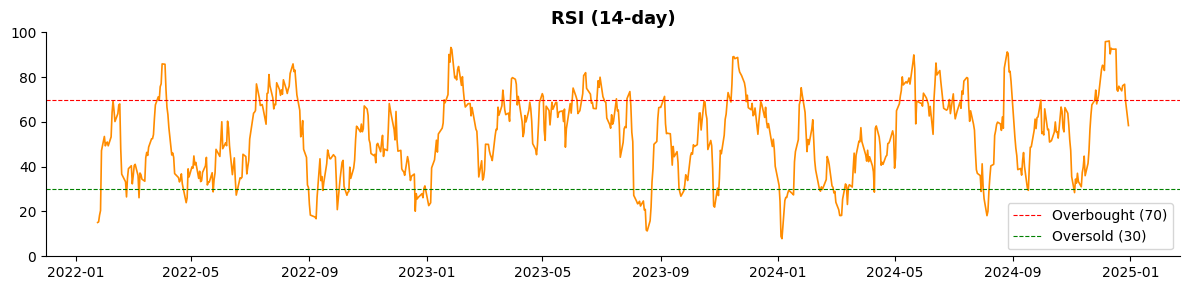

In [7]:
# Now we build RSI

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_rsi(df['Close'])

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df.index, df['RSI'], color='darkorange', linewidth=1.2)
ax.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
ax.set_title('RSI (14-day)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# We see that there is a new column - RSI
df.head(20)

Price,Close,High,Low,Open,Volume,MA5,MA20,RSI
Date,,,,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900,NaN,NaN,NaN
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400,NaN,NaN,NaN
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600,NaN,NaN,NaN
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000,NaN,NaN,NaN
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100,172.220547,NaN,NaN
2022-01-10,168.339310,168.642375,164.409205,165.298858,106765600,170.300461,NaN,NaN
2022-01-11,171.164673,171.262428,166.999945,168.466400,76138300,169.397125,NaN,NaN
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200,169.516397,NaN,NaN
2022-01-13,168.339310,172.670234,167.948246,171.849023,84505800,169.553540,NaN,NaN


### 4c — Create new features: Return, Volume_change, Return_lag1

In [9]:
# NDaily return
df['Return'] = df['Close'].pct_change()

# Add more features (volume, momentum, lag returns)
df['Volume_change'] = df['Volume'].pct_change()
df['Return_lag1']   = df['Return'].shift(1) # # yesterday's return → you DO know this before market opens

In [10]:
df.head(10)

Price,Close,High,Low,Open,Volume,MA5,MA20,RSI,Return,Volume_change,Return_lag1
Date,,,,,,,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400,NaN,NaN,NaN,-0.012692,-0.049551,NaN
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600,NaN,NaN,NaN,-0.026600,-0.048059,-0.012692
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000,NaN,NaN,NaN,-0.016693,0.025031,-0.026600
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100,172.220547,NaN,NaN,0.000988,-0.105206,-0.016693
2022-01-10,168.339310,168.642375,164.409205,165.298858,106765600,170.300461,NaN,NaN,0.000116,0.231308,0.000988
2022-01-11,171.164673,171.262428,166.999945,168.466400,76138300,169.397125,NaN,NaN,0.016784,-0.286865,0.000116
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200,169.516397,NaN,NaN,0.002570,-0.017509,0.016784
2022-01-13,168.339310,172.670234,167.948246,171.849023,84505800,169.553540,NaN,NaN,-0.019028,0.129678,0.002570


---
## 🎯 Section 5 — Create the Target Variable

We want to predict **next-day** movement:

$$\text{Target} = \begin{cases} 1 & \text{if } \text{Close}_{t+1} > \text{Close}_t \\ 0 & \text{otherwise} \end{cases}$$

In [11]:
# Target: will NEXT day's price be higher? (shift -1 to look forward)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [12]:
df.head(20)

Price,Close,High,Low,Open,Volume,MA5,MA20,RSI,Return,Volume_change,Return_lag1,Target
Date,,,,,,,,,,,,
2022-01-03,177.939743,178.790298,173.735915,173.853227,104487900,NaN,NaN,NaN,NaN,NaN,NaN,0
2022-01-04,175.681351,178.848900,175.114320,178.545835,99310400,NaN,NaN,NaN,-0.012692,-0.049551,NaN,0
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600,NaN,NaN,NaN,-0.026600,-0.048059,-0.012692,0
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000,NaN,NaN,NaN,-0.016693,0.025031,-0.026600,1
2022-01-07,168.319778,170.245725,167.205273,169.023678,86709100,172.220547,NaN,NaN,0.000988,-0.105206,-0.016693,1
2022-01-10,168.339310,168.642375,164.409205,165.298858,106765600,170.300461,NaN,NaN,0.000116,0.231308,0.000988,1
2022-01-11,171.164673,171.262428,166.999945,168.466400,76138300,169.397125,NaN,NaN,0.016784,-0.286865,0.000116,1
2022-01-12,171.604630,173.217725,170.910516,172.181432,74805200,169.516397,NaN,NaN,0.002570,-0.017509,0.016784,0
2022-01-13,168.339310,172.670234,167.948246,171.849023,84505800,169.553540,NaN,NaN,-0.019028,0.129678,0.002570,1


In [13]:
# Drop rows with NaN (from rolling windows)
df_clean = df[['RSI', 'MA5', 'MA20', 'Return', 'Volume_change', 'Return_lag1', 'Target']].dropna()


print(f'Dataset size after cleaning: {df_clean.shape[0]} rows')
print(f"\nTarget distribution:")
counts = df_clean['Target'].value_counts()
print(f"  UP   (1): {counts[1]} days ({counts[1]/len(df_clean)*100:.1f}%)")
print(f"  DOWN (0): {counts[0]} days ({counts[0]/len(df_clean)*100:.1f}%)")

Dataset size after cleaning: 733 rows

Target distribution:
  UP   (1): 392 days (53.5%)
  DOWN (0): 341 days (46.5%)


In [15]:
df_clean.head(5)

Price,RSI,MA5,MA20,Return,Volume_change,Return_lag1,Target
Date,,,,,,,
2022-01-31,53.502864,161.075479,166.062891,0.026126,-0.357873,0.069778,0
2022-02-01,49.313896,163.975143,165.701163,-0.000973,-0.253828,0.026126,1
2022-02-02,50.442480,167.132913,165.512481,0.007044,-0.015074,-0.000973,0
2022-02-03,51.025096,169.807727,165.413738,-0.016720,0.053039,0.007044,0
2022-02-04,49.323860,170.253470,165.443539,-0.001679,-0.077755,-0.016720,0


In [16]:
# Quick look at descriptive stats for few of our features

df_clean[['RSI', 'MA5', 'MA20', 'Return']].describe().round(3)

Price,RSI,MA5,MA20,Return
count,733.000,733.000,733.000,733.000
mean,53.814,175.772,174.888,0.001
std,17.912,29.292,27.979,0.017
min,7.865,125.075,128.759,-0.059
25%,39.833,152.833,152.728,-0.008
50%,54.475,170.886,171.440,0.001
75%,67.678,189.131,187.467,0.010
max,96.163,254.886,247.686,0.089


---
## 🤖 Section 6 — Train the Logistic Regression Model

**Steps:**
1. Select features (X) and label (y)
2. Split into train/test sets — **never test on data you trained on!**
3. Scale features — logistic regression is sensitive to scale
4. Fit the model

In [16]:
# Step 1 — Features and label
X = df_clean[['RSI', 'MA5', 'MA20', 'Volume_change', 'Return_lag1']]
y = df_clean['Target']

# Step 2 — Train / test split (80% train, 20% test, time-ordered)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False  # shuffle=False preserves time order
)

print(f'Training samples : {len(X_train)}')
print(f'Test samples     : {len(X_test)}')

Training samples : 586
Test samples     : 147


In [19]:
# Lets look at few records of train

X_train.iloc[0:3]
# X_test.iloc[0:3]

Price,RSI,MA5,MA20,Volume_change,Return_lag1
Date,,,,,
2022-01-31,53.502864,161.075479,166.062891,-0.357873,0.069778
2022-02-01,49.313896,163.975143,165.701163,-0.253828,0.026126
2022-02-02,50.442480,167.132913,165.512481,-0.015074,-0.000973


In [23]:
# Step 3 — Standardise features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

In [27]:
# compare actual vs scaled values
print(list(X_train.iloc[0]))
print((X_train_scaled[0]))

[53.502864452503275, 161.07547912597656, 166.062890625, -0.35787284013122467, 0.06977773695505785]
[ 0.0706431  -0.15334537  0.15106034 -1.4165033   3.89624435]


In [28]:
# Step 4 — Train logistic regression
model = LogisticRegression(class_weight='balanced',random_state=42)
model.fit(X_train_scaled, y_train)

print('✅ Model trained!')
print(f'\nTrain accuracy : {model.score(X_train_scaled, y_train):.3f}')
print(f'Test  accuracy : {model.score(X_test_scaled,  y_test):.3f}')

✅ Model trained!

Train accuracy : 0.543
Test  accuracy : 0.388


---
## 🔍 Section 7 — Understand the Model

### 7a — Coefficients

Each coefficient (β) tells us the **direction and strength** of each feature's influence on the prediction.

Intercept (β₀): 0.0009

      Feature  Coefficient Direction
          RSI     0.103775 ↑ Bullish
          MA5    -0.406252 ↓ Bearish
         MA20     0.285262 ↑ Bullish
Volume_change    -0.065997 ↓ Bearish
  Return_lag1    -0.167302 ↓ Bearish


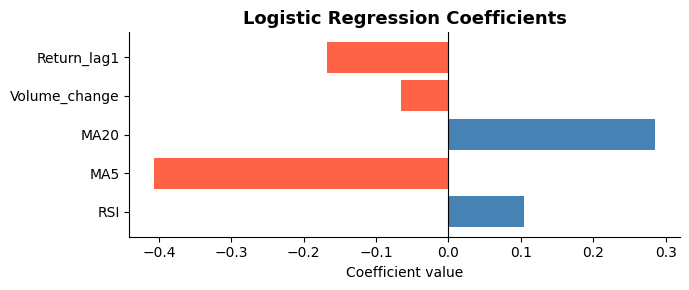

In [29]:
features = ['RSI', 'MA5', 'MA20', 'Volume_change', 'Return_lag1']
coefs    = model.coef_[0]

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
coef_df['Direction'] = coef_df['Coefficient'].apply(lambda x: '↑ Bullish' if x > 0 else '↓ Bearish')

print(f'Intercept (β₀): {model.intercept_[0]:.4f}\n')
print(coef_df.to_string(index=False))

# Bar chart
colors = ['tomato' if c < 0 else 'steelblue' for c in coefs]
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(features, coefs, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients', fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

### 7b — Visualise the Sigmoid Function

This is the core of logistic regression — the S-shaped curve that maps any value to (0, 1).

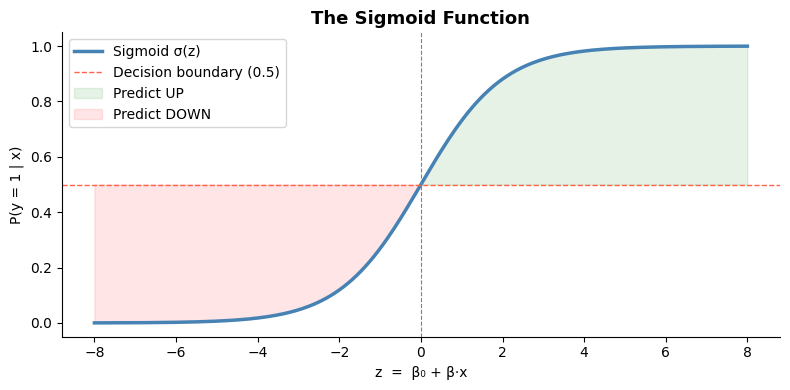

In [30]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(z, sigmoid,
        color='steelblue',
        linewidth=2.5,
        label='Sigmoid σ(z)'
)

ax.axhline(0.5, color='tomato', linestyle='--', linewidth=1, label='Decision boundary (0.5)')
ax.axvline(0,   color='gray',   linestyle='--', linewidth=0.8)
ax.fill_between(z, 0.5, sigmoid, where=(sigmoid > 0.5), alpha=0.1, color='green', label='Predict UP')
ax.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.1, color='red',   label='Predict DOWN')
ax.set_title('The Sigmoid Function', fontsize=13, fontweight='bold')
ax.set_xlabel('z  =  β₀ + β·x')
ax.set_ylabel('P(y = 1 | x)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 📊 Section 8 — Evaluate the Model

### 8a — Confusion Matrix

confusion matrix:
 [[52  4]
 [75 16]]


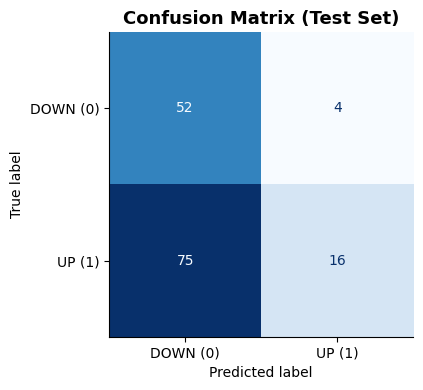

In [31]:
# This line already exists in your notebook — y_prob is created here
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# NOTE: Play around with this number in class
y_pred = (y_prob > 0.45).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['DOWN (0)', 'UP (1)'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 8b — Classification Report

| Metric | Meaning |
|--------|----------|
| **Precision** | Of all predicted UPs, how many were actually UP? |
| **Recall** | Of all actual UPs, how many did we catch? |
| **F1-Score** | Harmonic mean of precision and recall |

In [32]:
print(classification_report(y_test, y_pred, target_names=['DOWN (0)', 'UP (1)']))

              precision    recall  f1-score   support

    DOWN (0)       0.41      0.93      0.57        56
      UP (1)       0.80      0.18      0.29        91

    accuracy                           0.46       147
   macro avg       0.60      0.55      0.43       147
weighted avg       0.65      0.46      0.39       147



## This is the classic tradeoff:

- When the model does predict UP, it's right 80% of the time (high precision) — but it only catches 18% of actual UP days (low recall)
- It's being very conservative about calling UP, which in finance is actually reasonable — you'd rather miss opportunities than make bad trades


### 8c — ROC Curve & AUC

The **ROC curve** shows the trade-off between true positives and false positives at different thresholds. **AUC = 1.0** is perfect; **AUC = 0.5** is random guessing.

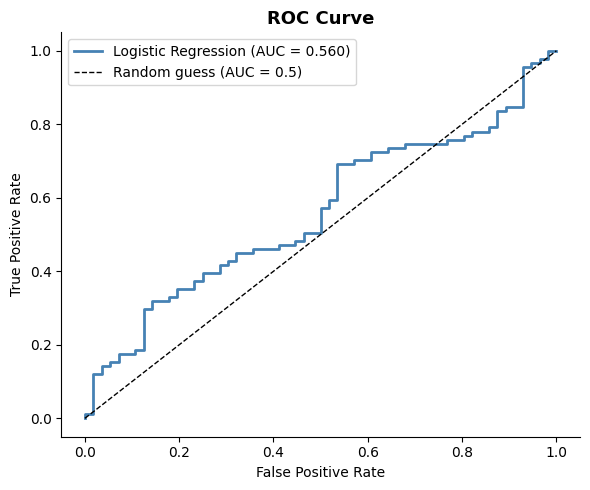

In [33]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 💡 Section 9 — Make a Prediction (Live Example)

Let's manually predict whether the stock will go up tomorrow given hypothetical indicator values.

In [34]:
print(X_train.iloc[0])        # first row
print(y_train[0])

Price
RSI               53.502864
MA5              161.075479
MA20             166.062891
Volume_change     -0.357873
Return_lag1        0.069778
Name: 2022-01-31 00:00:00, dtype: float64
0


In [35]:
# --- Change these values and re-run! ---
rsi_today  =  53    # RSI between 0–100  
ma5_today  = 161   # 5-day average price
ma20_today = 166    # 20-day average price
volume_change_today = -0.35
return_lag1_today = 0.069

# ---------------------------------------

new_data = np.array([[rsi_today, ma5_today, ma20_today, volume_change_today, return_lag1_today]])
new_data_scaled = scaler.transform(new_data)

probability = model.predict_proba(new_data_scaled)[0][1]
prediction  = model.predict(new_data_scaled)[0]

label = 'UP' if prediction == 1 else 'DOWN'
# print(f'Input  → RSI={rsi_today}, MA5={ma5_today}, MA20={ma20_today}')
print(f'Input  → {new_data}')

print(f'P(UP)  → {probability:.3f}')
print(f'Prediction → {label}')

Input  → [[ 5.30e+01  1.61e+02  1.66e+02 -3.50e-01  6.90e-02]]
P(UP)  → 0.391
Prediction → DOWN


---
## 🧪 Section 10 — Student Exercises

Try these on your own:

1. **Change the stock** — Replace `'AAPL'` with `'MSFT'`, `'TSLA'`, or `'GOOGL'`. Does the model accuracy change?

2. **Add a new feature** — Volume is often a predictor of price movement. Add `df['Volume']` as a feature and retrain. Did AUC improve?

3. **Change the threshold** — Instead of using 0.5 to classify UP/DOWN, try 0.55. Does precision improve? What happens to recall?
   ```python
   y_pred_custom = (y_prob > 0.55).astype(int)
   ```

4. **Try a different RSI period** — Replace `period=14` in `compute_rsi()` with `period=7` (faster) or `period=21` (slower). How does it affect the model?

5. **Interpret the coefficients** — If RSI has a negative coefficient, what does that mean financially?

---

## ⚠️ Key Takeaways & Caveats

- Logistic regression is **interpretable** and a great baseline model
- Stock markets are **highly efficient** — even a 55% accuracy is meaningful
- This model does **not** account for transaction costs, slippage, or regime changes
- Always test on **out-of-sample** (future) data; never on training data
- A model that works on AAPL 2022–2024 may not work in 2025

> *"All models are wrong, but some are useful."* — George Box